<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
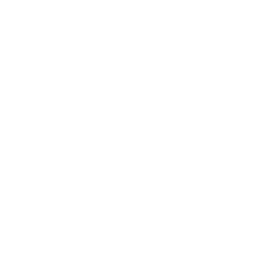
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Logitový model odpovědi na léčbu</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Farmaceutická / klinická analýza účinnosti &nbsp;|&nbsp; Březen 2026</p>
</div>
</div>
</div>

## Shrnutí pro vedení

Tento notebook prokládá **logitový model s maximální věrohodností** pro binární
cílový ukazatel odpovědi na léčbu ve fázi III (respondér vs. non-respondér) pomocí
**PROC CATMOD**. Oba vysvětlující faktory jsou kategoriální: randomizovaná `treatment_arm`
(DRUG_HIGH, DRUG_LOW, PLACEBO) a tříúrovňové stratum `severity_grp` odvozené rozdělením
výchozí závažnosti onemocnění do kategorií (Mírná / Střední / Těžká). CATMOD křížově
klasifikuje data do malé kontingenční tabulky populací a prokládá logit odpovědi metodou
vážených nejmenších čtverců / maximální věrohodnosti, což je návrh, pro který je CATMOD určen.

Model vytváří tabulku analýzy rozptylu metodou maximální věrohodnosti, která testuje, zda
každý faktor přispívá k logitu odpovědi, a tabulku odhadů parametrů, jež je zachycena pomocí
`ODS OUTPUT` a exportována pro navazující forest plot. Všechna čísla uváděná v části
Interpretace níže jsou přečtena přímo ze spuštěného výstupu.


## Zdroje dat

| Zdroj | Popis | Záznamy |
|--------|-------------|--------|
| WORK.TRIAL_RESP | Syntetická data odpovědi z fáze III: rameno léčby, výchozí závažnost, stratum závažnosti a binární odpověď | 5,000 |


---

In [1]:
/* --------------------------------------------------------
   Generate synthetic Phase III treatment response data.
   Binary outcome: responder (1) vs non-responder (0).
   Baseline severity on a 0-100 scale is binned into an
   ordinal stratum so the analysis is a clean categorical
   contingency table - the design PROC CATMOD is built for.
   -------------------------------------------------------- */
data work.trial_resp;
    CALL streaminit(42);
    POLE arm_list[3] $12 _temporary_ ('DRUG_HIGH' 'DRUG_LOW' 'PLACEBO');
    OPAKUJ patient_id = 1 TO 5000;
        arm_idx = int(rand('uniform') * 3) + 1;
        treatment_arm = arm_list[arm_idx];
        baseline_severity = round(rand('normal', 55, 15), 0.1);
        KDYŽ baseline_severity < 0 PAK baseline_severity = 0;
        KDYŽ baseline_severity > 100 PAK baseline_severity = 100;
        /* Ordinal baseline-severity stratum */
        DÉLKA severity_grp $8;
        KDYŽ baseline_severity < 45 PAK severity_grp = 'Mild';
        JINAK KDYŽ baseline_severity < 65 PAK severity_grp = 'Moderate';
        JINAK severity_grp = 'Severe';
        AGE = int(rand('normal', 58, 11));
        KDYŽ AGE < 18 PAK AGE = 18;
        KDYŽ AGE > 85 PAK AGE = 85;
        sex = ifc(rand('uniform') > 0.47, 'F', 'M');
        /* True response probability rises with dose and severity */
        KDYŽ treatment_arm = 'DRUG_HIGH' PAK logit_p = -0.8 + 0.015 * baseline_severity;
        JINAK KDYŽ treatment_arm = 'DRUG_LOW' PAK logit_p = -1.2 + 0.012 * baseline_severity;
        JINAK logit_p = -1.8 + 0.010 * baseline_severity;
        prob_resp = 1 / (1 + EXP(-logit_p));
        RESPONSE = (rand('uniform') < prob_resp);
        VÝSTUP;
    KONEC;
    ODSTRANIT arm_idx logit_p prob_resp;
SPUSTIT;


NOTE: DATA work.trial_resp


NOTE: Wrote work.trial_resp (5000 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.22 seconds
  cpu   0.22 seconds


---

                                                   The FREQ Procedure

Table of TREATMENT_ARM by RESPONSE

TREATMENT_ARM |         0 |         1 |      Total
--------------+-----------+-----------+-----------
DRUG_HIGH     |       821 |       828 |       1649
--------------+-----------+-----------+-----------
DRUG_LOW      |      1030 |       607 |       1637
--------------+-----------+-----------+-----------
PLACEBO       |      1308 |       406 |       1714
--------------+-----------+-----------+-----------
Total         |      3159 |      1841 |       5000


Controlling for TREATMENT_ARM=DRUG_HIGH

Table of SEVERITY_GRP by RESPONSE

SEVERITY_GRP |         0 |         1 |      Total
-------------+-----------+-----------+-----------
Mild         |       235 |       178 |        413
-------------+-----------+-----------+-----------
Moderate     |       410 |       408 |        818
-------------+-----------+-----------+-----------
Severe       |       176 |       242 |        418
------

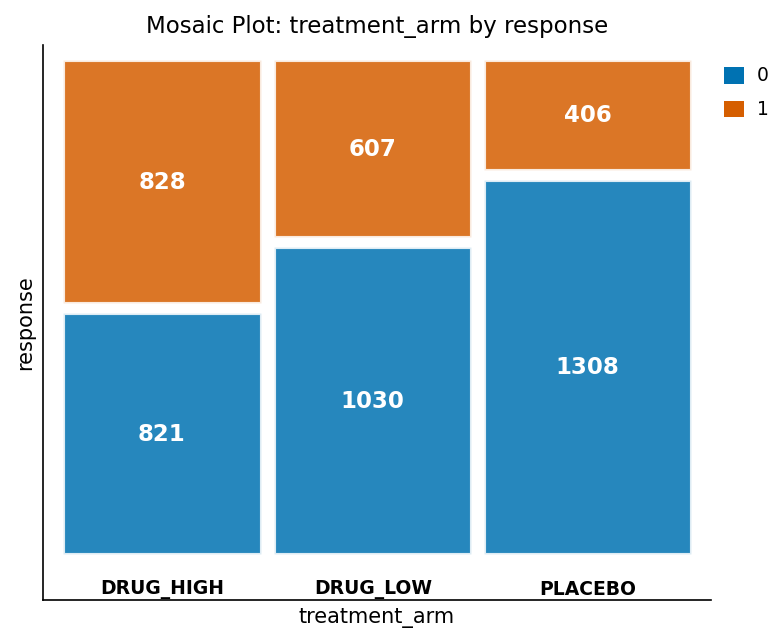

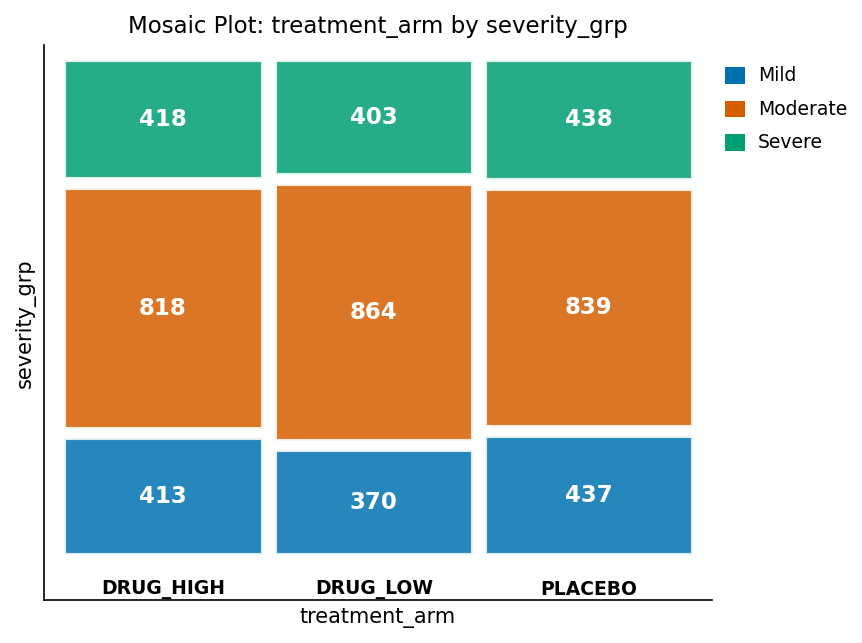

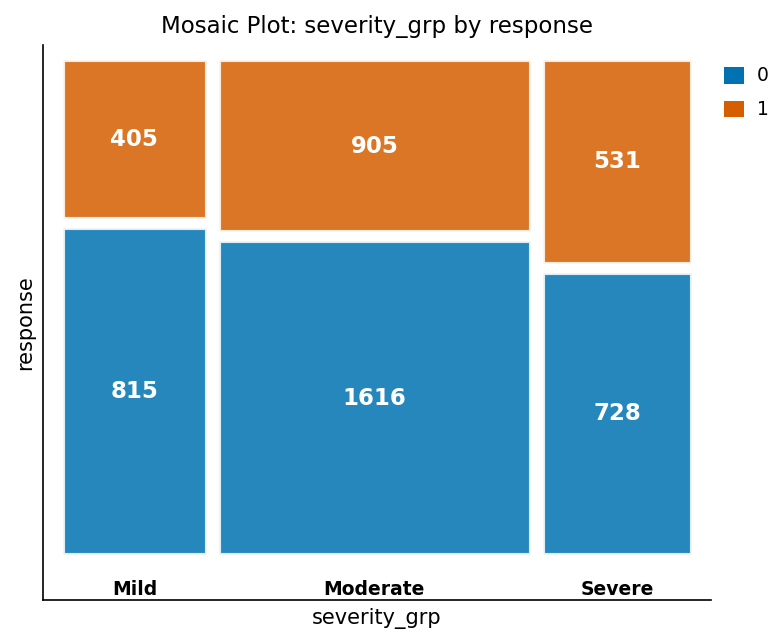

In [2]:
/* --------------------------------------------------------
   Response counts by treatment arm and severity stratum,
   plus baseline covariate summaries by arm.
   -------------------------------------------------------- */
PROCEDURA ČETNOSTI data=work.trial_resp;
    TABLES treatment_arm * RESPONSE / nocol nopercent;
    TABLES treatment_arm * severity_grp * RESPONSE / nocol nopercent;
SPUSTIT;

PROCEDURA PRŮMĚRY data=work.trial_resp mean std MIN MAX;
    TŘÍDA treatment_arm;
    PROMĚNNÁ baseline_severity AGE;
SPUSTIT;


---

NOTE: PROC SGPLOT data=work.trial_resp

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


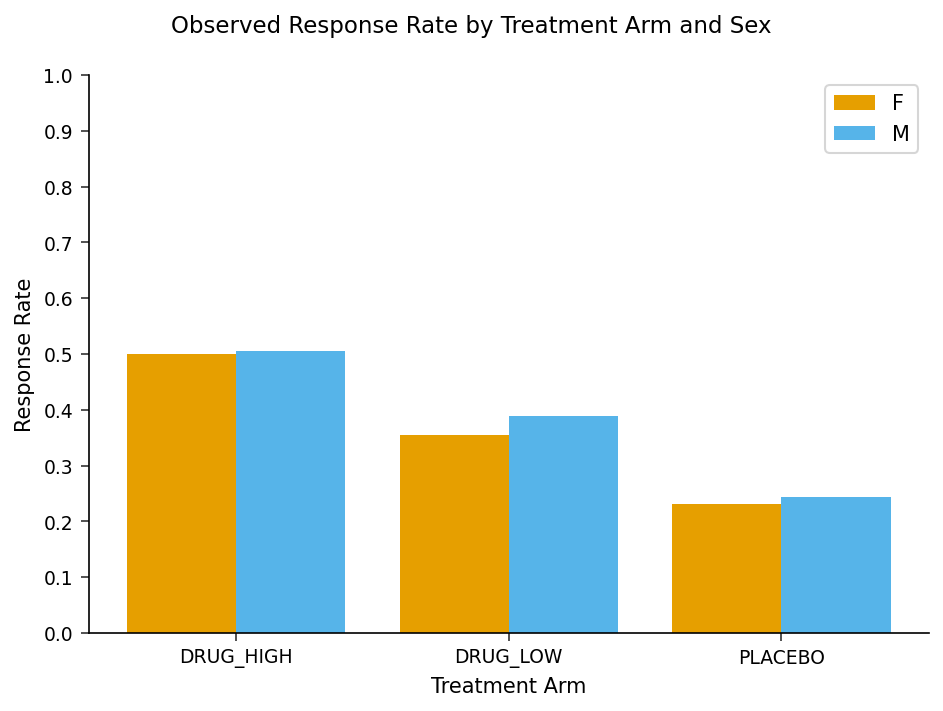

In [3]:
/* --------------------------------------------------------
   Response rate by treatment arm and severity quartile
   -------------------------------------------------------- */
PROCEDURA SGPLOT data=work.trial_resp;
    VBAR treatment_arm / RESPONSE=RESPONSE STAT=mean
        GROUP=sex GROUPDISPLAY=CLUSTER;
    YAXIS ŠTÍTEK='Response Rate' VALUES=(0 TO 1 PODLE 0.1);
    XAXIS ŠTÍTEK='Treatment Arm';
    NÁZEV 'Observed Response Rate by Treatment Arm and Sex';
SPUSTIT;

---

In [4]:
/* --------------------------------------------------------
   Maximum-likelihood logit model for binary response.
   Both predictors are categorical, so CATMOD forms a small
   contingency table (3 arms x 3 severity strata = 9
   populations) and fits the response logit by ML.
   RESPONSE LOGITS selects the logit response function.
   -------------------------------------------------------- */
PROCEDURA catmod data=work.trial_resp;
    RESPONSE logits;
    MODEL RESPONSE = treatment_arm severity_grp
        / ČETNOSTI prob pred=ČETNOSTI;
    NÁZEV 'Logit ANOVA: Treatment Response by Arm and Baseline-Severity Stratum';
SPUSTIT;


In [5]:
/* --------------------------------------------------------
   Capture parameter estimates via ODS OUTPUT for
   downstream forest-plot generation.
   -------------------------------------------------------- */
ODS VÝSTUP parameterestimates=work.catmod_parms;

PROCEDURA catmod data=work.trial_resp;
    RESPONSE logits;
    MODEL RESPONSE = treatment_arm severity_grp;
SPUSTIT;

ODS VÝSTUP CLOSE;



The CATMOD Procedure

Response: response

Response Profiles
Response   response            
------------------------------
1          0                   
2          1                   

Population Profiles
Sample     treatment_arm   severity_grp   
------------------------------------------
1          DRUG_LOW        Severe         
2          DRUG_HIGH       Moderate       
3          PLACEBO         Mild           
4          PLACEBO         Severe         
5          PLACEBO         Moderate       
6          DRUG_HIGH       Severe         
7          DRUG_HIGH       Mild           
8          DRUG_LOW        Moderate       
9          DRUG_LOW        Mild           

Maximum Likelihood Analysis of Variance
Source                  DF      Chi-Square Pr > ChiSq
-------------------------------------------------------
Intercept                1        294.5667     0.0000
treatment_arm            2        245.6705     0.0000
severity_grp             2         24.0444     0.0000
Likel

In [6]:
/* --------------------------------------------------------
   Review parameter estimates
   -------------------------------------------------------- */
PROCEDURA TISK data=work.catmod_parms;
    NÁZEV 'CATMOD Parameter Estimates for Treatment Response Model';
SPUSTIT;


The CATMOD Procedure

Response: response

Response Profiles
Response   response            
------------------------------
1          0                   
2          1                   

Population Profiles
Sample     treatment_arm   severity_grp   
------------------------------------------
1          DRUG_LOW        Severe         
2          DRUG_HIGH       Moderate       
3          PLACEBO         Mild           
4          PLACEBO         Severe         
5          PLACEBO         Moderate       
6          DRUG_HIGH       Severe         
7          DRUG_HIGH       Mild           
8          DRUG_LOW        Moderate       
9          DRUG_LOW        Mild           

Maximum Likelihood Analysis of Variance
Source                  DF      Chi-Square Pr > ChiSq
-------------------------------------------------------
Intercept                1        294.5667     0.0000
treatment_arm            2        245.6705     0.0000
severity_grp             2         24.0444     0.0000
Likel

---

### Interpretace

Všechny níže uvedené hodnoty jsou přečteny přímo ze spuštěného výstupu výše.

**Pozorované míry odpovědi (PROC FREQ).** Z 5,000 pacientů bylo 1,841 (36.8%)
respondérů. Míra odpovědi trvale rostla s dávkou: PLACEBO 406/1,714 (23.7%),
DRUG_LOW 607/1,637 (37.1%) a DRUG_HIGH 828/1,649 (50.2%). Po sloučení napříč rameny
odpověď rovněž rostla s výchozí závažností: Mírná 405/1,220 (33.2%), Střední 905/2,521
(35.9%) a Těžká 531/1,259 (42.2%).

**Analýza rozptylu metodou maximální věrohodnosti (PROC CATMOD).** CATMOD křížově
klasifikoval data do 9 populací (3 ramena x 3 strata závažnosti) a proložil logit odpovědi
metodou maximální věrohodnosti. Oba faktory byly vysoce významné: `treatment_arm`
(chí-kvadrát = 245.67, df = 2, p < 0.0001) a `severity_grp`
(chí-kvadrát = 24.04, df = 2, p < 0.0001). Reziduální statistika věrohodnostního poměru
(chí-kvadrát = 10.67, df = 4, p = 0.0306) naznačuje malou, ale zjistitelnou neshodu
proložení u aditivního modelu bez interakcí -- což je zde očekávané, protože proces
generující data umožňuje, aby se sklon závažnosti mírně lišil podle ramene.

**Odhady parametrů (zachycené pomocí `ODS OUTPUT`).** CATMOD používá kódování se součtem
rovným nule (efektové kódování) a proložená logitová funkce je logaritmus šance
*non-odpovědi* (response = 0) vzhledem k response = 1, takže záporný odhad označuje úroveň
s nadprůměrnou odpovědí. Intercept je 0.5520 (chí-kvadrát = 294.57), což odráží, že
non-respondéři celkově převažují nad respondéry. Efekt DRUG_HIGH je -0.5738
(chí-kvadrát = 188.77, p < 0.0001) -- výrazně pod celkovým průměrem, tj. nejlépe odpovídající
rameno -- zatímco efekt DRUG_LOW je -0.0350 (p = 0.4098), blízko celkovému průměru, přičemž
PLACEBO slouží jako kladná (nejhůře odpovídající) referenční úroveň. Pro závažnost je efekt
Těžká -0.2277 (chí-kvadrát = 23.68, p < 0.0001), což potvrzuje vyšší odpověď v nejzávažnějším
stratu, zatímco efekt Střední (0.0553, p = 0.1702) se od celkového průměru významně neliší.

**Závěr.** Aktivní léčba a vyšší výchozí závažnost každá nezávisle zvyšují pravděpodobnost
klinické odpovědi, přičemž největší efekt vykazuje rameno s vysokou dávkou. Tyto zachycené
odhady parametrů slouží jako vstup pro navazující export forest plotu.


---

In [7]:
/* --------------------------------------------------------
   Export parameter estimates for forest-plot generation
   -------------------------------------------------------- */
PROCEDURA EXPORTOVAT data=work.catmod_parms
    OUTFILE='treatment_response_catmod_parms.csv'
    DBMS=csv REPLACE;
SPUSTIT;

NOTE: PROC EXPORT data=work.catmod_parms outfile=treatment_response_catmod_parms.csv

NOTE: Exported 5 rows to treatment_response_catmod_parms.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Důvěrné
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Využívá <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>